In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv("C:/Users/sanja/Desktop/deep learning/Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
df.drop('CustomerId',axis='columns',inplace=True)

In [4]:
df.head()

,RowNumber,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.drop('RowNumber',axis='columns',inplace=True)

In [7]:
df.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.drop('Surname',axis='columns',inplace=True)

In [41]:
df.isna().sum()

CreditScore        10000
Geography          10000
Gender             10000
Age                10000
Tenure             10000
Balance            10000
NumOfProducts      10000
HasCrCard          10000
IsActiveMember     10000
EstimatedSalary    10000
Exited             10000
dtype: int64

In [9]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [13]:
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [14]:
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [20]:
df['Gender']=df['Gender'].replace({'Female':0,'Male':1})

In [21]:
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7161,690,France,0,36,6,110480.48,1,0,0,81292.33,0
3430,625,France,1,37,1,177069.24,2,1,1,96088.54,0
376,745,Germany,1,45,10,117231.63,3,1,1,122381.02,1
8415,760,Spain,1,38,3,91241.85,1,0,1,80682.35,0
8580,529,France,0,31,6,152310.55,1,1,0,13054.25,0


In [22]:
df1=pd.get_dummies(data=df,columns=['Geography'],dtype=int)
df1.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [26]:
cols_to_scale=['CreditScore','Balance','EstimatedSalary']
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df1[cols_to_scale]=scaler.fit_transform(df1[cols_to_scale])

In [27]:
df1.sample(4)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
4810,0.564,1,38,4,0.000000,2,0,0,0.962562,0,1,0,0
5448,0.516,0,44,5,0.502785,1,0,1,0.662129,1,0,1,0
6795,0.454,1,48,6,0.716834,1,1,0,0.967936,0,0,0,1
7735,0.386,1,41,6,0.571349,1,1,1,0.960385,1,0,1,0


CreditScore        526
Geography          526
Gender             526
Age                526
Tenure             526
Balance            526
NumOfProducts      526
HasCrCard          526
IsActiveMember     526
EstimatedSalary    526
Exited             526
dtype: int64

In [46]:
df1.dtypes

CreditScore          float64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_France       int64
Geography_Germany      int64
Geography_Spain        int64
dtype: object

In [45]:
df1['Gender']=df['Gender'].astype(int)

In [48]:
df_es=df1[df1['Exited']==0].EstimatedSalary	
df_es_1=df1[df1['Exited']==1].EstimatedSalary

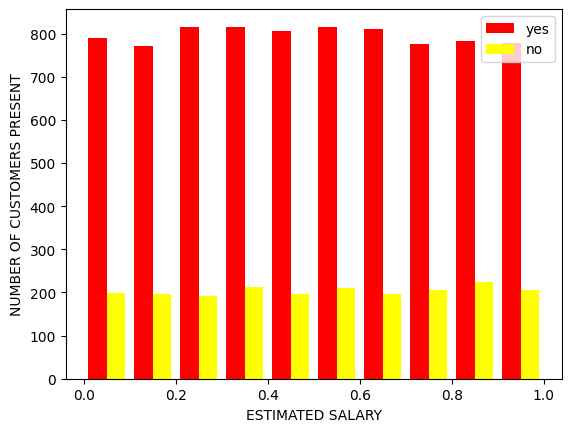

In [51]:
plt.xlabel('ESTIMATED SALARY')
plt.ylabel('NUMBER OF CUSTOMERS PRESENT')

plt.hist([df_es,df_es_1],color=['red','yellow'],label=['yes','no'])
plt.legend()

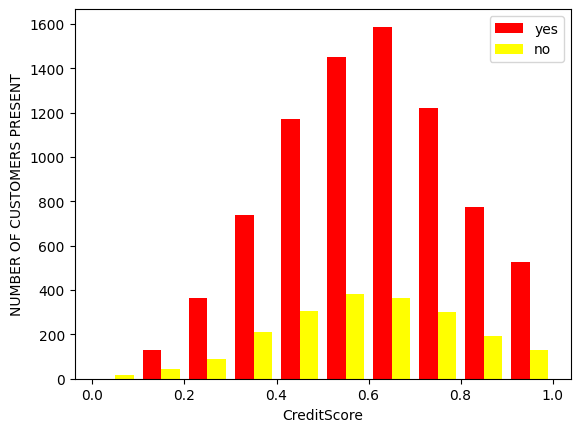

In [53]:
df_cs=df1[df1['Exited']==0].CreditScore	
df_cs_1=df1[df1['Exited']==1].CreditScore
plt.xlabel('CreditScore')
plt.ylabel('NUMBER OF CUSTOMERS PRESENT')

plt.hist([df_cs,df_cs_1],color=['red','yellow'],label=['yes','no'])
plt.legend()

In [54]:
df1.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,0.538,0,42,2,0.000000,1,1,1,0.506735,1,1,0,0
1,0.516,0,41,1,0.334031,1,0,1,0.562709,0,0,0,1
2,0.304,0,42,8,0.636357,3,1,0,0.569654,1,1,0,0
3,0.698,0,39,1,0.000000,2,0,0,0.469120,0,1,0,0
4,1.000,0,43,2,0.500246,1,1,1,0.395400,0,0,0,1


In [59]:
df['NumOfProducts'].unique()

array([1, 3, 2, 4])

In [58]:
col=[ 'Geography', 'Gender',  'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited']
for i in col:
    print(df[i].unique())

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str
[0 1]
[ 2  1  8  7  4  6  3 10  5  9  0]
[0.         0.33403148 0.63635718 ... 0.22865702 0.29922631 0.51870777]
[1 3 2 4]
[1 0]
[1 0]
[0.50673489 0.56270874 0.56965435 ... 0.21039009 0.46442905 0.19091423]
[1 0]


In [60]:
cols_to_scale=['Tenure','Age','NumOfProducts']
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df1[cols_to_scale]=scaler.fit_transform(df1[cols_to_scale])

In [61]:
df1.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,0.538,0,0.324324,0.2,0.000000,0.000000,1,1,0.506735,1,1,0,0
1,0.516,0,0.310811,0.1,0.334031,0.000000,0,1,0.562709,0,0,0,1
2,0.304,0,0.324324,0.8,0.636357,0.666667,1,0,0.569654,1,1,0,0
3,0.698,0,0.283784,0.1,0.000000,0.333333,0,0,0.469120,0,1,0,0
4,1.000,0,0.337838,0.2,0.500246,0.000000,1,1,0.395400,0,0,0,1


In [64]:
import tensorflow 
from tensorflow import keras

In [65]:
import numpy as np

In [127]:
from sklearn.metrics import classification_report

In [148]:
def ANN(xtrain,ytrain,xtest,ytest,loss,weight):
    model=keras.Sequential([
        keras.layers.Dense(32,input_shape=(12,),activation='relu'),
        keras.layers.Dense(16,'relu'),
        keras.layers.Dense(1,'sigmoid')
    ])
    model.compile(optimizer='adam',loss=loss,metrics=['accuracy'])
    if weight==-1:
         model.fit(xtrain, ytrain, epochs=100)
    else:
         model.fit(xtrain, ytrain, epochs=100,class_weight = weights)
    print(model.evaluate(xtest, ytest))
    
    y_preds = model.predict(xtest)
    y_preds = np.round(y_preds)
    
    print("Classification Report: \n", classification_report(ytest, y_preds))
    
    return y_preds

In [ ]:
#dataset is imbalanced so need to make sure the distribtuion is equal and fair else leading to a biased model!

In [71]:
count_0,count_1=df1.Exited.value_counts()

In [72]:
print(count_0,count_1)

7963 2037


In [73]:
#under sampling the majority data!

In [110]:
df_class_0=df1[df1['Exited']==0]
df_class_1=df1[df1['Exited']==1]

In [111]:
df_class_0_under=df_class_0.sample(count_1)
df_train=pd.concat([df_class_0_under,df_class_1])

In [112]:
df_train['Exited'].value_counts()

Exited
0    2037
1    2037
Name: count, dtype: int64

In [113]:
df_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
9082,0.836,0,0.243243,0.5,0.718098,0.333333,1,0,0.086693,0,1,0,0
7518,0.300,1,0.162162,0.2,0.500186,0.333333,1,1,0.344012,0,0,1,0
5106,0.500,0,0.189189,0.1,0.313017,0.000000,1,0,0.321721,0,1,0,0
6987,0.364,1,0.567568,0.5,0.305725,0.333333,0,1,0.069397,0,1,0,0
9449,0.626,1,0.135135,0.8,0.492926,0.333333,1,1,0.439910,0,0,1,0


In [114]:
df_train.shape

(4074, 13)

In [115]:
from sklearn.model_selection import train_test_split
y=df_train['Exited']
x=df_train.drop('Exited',axis='columns')

In [116]:
x.drop('Geography_France',axis='columns')

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
9082,0.836,0,0.243243,0.5,0.718098,0.333333,1,0,0.086693,0,0
7518,0.300,1,0.162162,0.2,0.500186,0.333333,1,1,0.344012,1,0
5106,0.500,0,0.189189,0.1,0.313017,0.000000,1,0,0.321721,0,0
6987,0.364,1,0.567568,0.5,0.305725,0.333333,0,1,0.069397,0,0
9449,0.626,1,0.135135,0.8,0.492926,0.333333,1,1,0.439910,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9981,0.296,1,0.324324,0.3,0.605982,0.000000,1,1,0.267193,1,0
9982,0.610,0,0.378378,0.7,0.546617,0.000000,1,0,0.575729,1,0
9991,0.494,0,0.472973,0.4,0.352259,0.000000,1,0,0.346899,0,0
9997,0.718,0,0.243243,0.7,0.000000,0.000000,0,1,0.210390,0,0


In [117]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [119]:
print(ytrain.value_counts())

Exited
1    1630
0    1629
Name: count, dtype: int64


In [131]:
ANN(xtrain,ytrain,xtest,ytest,'binary_crossentropy',-1)

Epoch 1/100


C:\Users\sanja\.conda\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5670 - loss: 0.6761
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6352 - loss: 0.6423
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6640 - loss: 0.6238
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6766 - loss: 0.6113
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6836 - loss: 0.6005
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6935 - loss: 0.5919
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6990 - loss: 0.5838
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6971 - loss: 0.5758
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7054 - loss: 0.5702
Epoch 10/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7073 - loss: 0.5653
Epoch 11/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7091 - loss: 0.5605
Epoch 12/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

array([[1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],

In [138]:
#over sampling the minority class 
df_class_1_over=df_class_1.sample(n=count_0,replace=True,random_state=42)
df_train_over=pd.concat([df_class_1_over,df_class_0],axis=0)

In [140]:
df_train_over['Exited'].value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

In [141]:
df_train_over.shape

(15926, 13)

In [142]:
from sklearn.model_selection import train_test_split
y=df_train_over['Exited']
x=df_train_over.drop('Exited',axis='columns')

In [145]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [147]:
print(ytrain.value_counts())

Exited
0    6370
1    6370
Name: count, dtype: int64


In [149]:
ANN(xtrain,ytrain,xtest,ytest,'binary_crossentropy',-1)

Epoch 1/100


C:\Users\sanja\.conda\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6494 - loss: 0.6301
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7005 - loss: 0.5744
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7295 - loss: 0.5419
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7440 - loss: 0.5186
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7546 - loss: 0.5017
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7621 - loss: 0.4890
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7661 - loss: 0.4783
Epoch 8/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7681 - loss: 0.4728
Epoch 9/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7738 - loss: 0.4681
Epoch 10/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7741 - loss: 0.4639
Epoch 11/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7764 - loss: 0.4591
Epoch 12/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

array([[1.],
       [1.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(3186, 1), dtype=float32)

In [157]:
df1.shape

(10000, 13)

In [151]:
y=df1['Exited']
x=df1.drop('Exited',axis='columns')

In [155]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x, y)

y_sm.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

In [158]:
xtrain,xtest,ytrain,ytest=train_test_split(x_sm,y_sm,test_size=0.2,random_state=42)

In [160]:
ytrain.value_counts()

Exited
1    6410
0    6330
Name: count, dtype: int64

In [162]:
y_preds = ANN(xtrain, ytrain, xtest, ytest, 'binary_crossentropy', -1)

Epoch 1/100


C:\Users\sanja\.conda\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6507 - loss: 0.6278
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7113 - loss: 0.5698
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7356 - loss: 0.5292
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7596 - loss: 0.4929
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7699 - loss: 0.4738
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7710 - loss: 0.4657
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7758 - loss: 0.4597
Epoch 8/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7795 - loss: 0.4543
Epoch 9/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7809 - loss: 0.4509
Epoch 10/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7834 - loss: 0.4479
Epoch 11/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7858 - loss: 0.4444
Epoch 12/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [165]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(ytest,y_preds)
print(cm)

[[1290  343]
 [ 263 1290]]


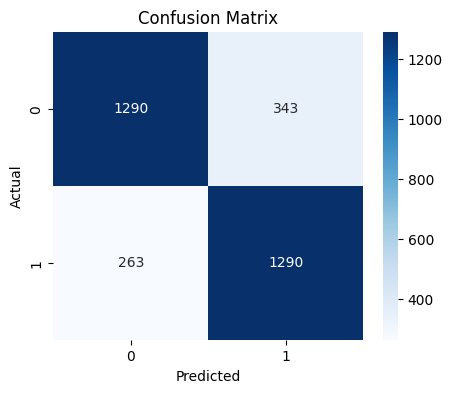

In [170]:
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()